In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib import cm

sns.set_context('notebook')
sns.set_style('whitegrid')
from iblatlas.atlas import BrainRegions

In [2]:
# Setup paths
prefix = '/home/ines/repositories/'
firing_rates_dir = prefix + 'representation_learning_variability/paper-individuality/data/firing_rates/'
clustering_dir = prefix + 'representation_learning_variability/paper-individuality/clustering/'

print(f"Firing rates directory: {firing_rates_dir}")
print(f"Clustering directory: {clustering_dir}")

Firing rates directory: /home/ines/repositories/representation_learning_variability/paper-individuality/data/firing_rates/
Clustering directory: /home/ines/repositories/representation_learning_variability/paper-individuality/clustering/


## Load and Average Firing Rate Data (Per-File Compression)

In [3]:
def load_and_average_firing_rates(firing_rates_dir, max_files=None):
    """
    Load firing rate files one at a time and average trials per neuron.
    This compresses data per-file to avoid loading 7.6M rows at once.
    
    For each file:
    - Load one file (~50k-100k rows per trial)
    - Average firing rates across trials for each (session, neuron) pair
    - Save compressed result
    
    Finally concatenate all compressed files.
    """
    pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
    if max_files:
        pkl_files = pkl_files[:max_files]

    compressed_dfs = []
    
    print(f"Processing {len(pkl_files)} files with per-file averaging...\n")
    
    for i, pkl_file in enumerate(pkl_files):
        try:
            # Load single file
            with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
                df = pickle.load(f)
            
            original_rows = len(df)
            
            # Identify time columns (PSTH firing rates)
            time_cols = [col for col in df.columns if col.startswith('t_')]
            
            # Average firing rates across trials per neuron per session
            # IMPORTANT: Only average time columns (can't average string columns like session, area, pid)
            compressed = df.groupby(['session', 'neuron_id'])[time_cols].mean().reset_index()

            # Add back metadata columns using .first() since they're the same for each group
            metadata = df.groupby(['session', 'neuron_id']).agg({
                'area': 'first',
                'pid': 'first'
            }).reset_index()

            compressed = compressed.merge(metadata, on=['session', 'neuron_id'])
            
            compressed_dfs.append(compressed)
            
            compression_ratio = original_rows / len(compressed) if len(compressed) > 0 else 1
            
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  [{i + 1:3d}/{len(pkl_files)}] {original_rows:7d} rows → {len(compressed):4d} (compressed {compression_ratio:6.0f}x)")
                
        except Exception as e:
            print(f"Error processing {pkl_file}: {e}")
            import traceback
            traceback.print_exc()
    
    # Concatenate all compressed files
    if compressed_dfs:
        print(f"\n✓ All files processed and averaged")
        combined_df = pd.concat(compressed_dfs, ignore_index=True)
        print(f"✓ Final shape: {combined_df.shape}")
        return combined_df
    return None

print("Loading and averaging firing rate files...")
firing_rates_full = load_and_average_firing_rates(firing_rates_dir)
print(f"\n✓ Total sessions: {firing_rates_full['session'].nunique()}")
print(f"✓ Total neurons: {firing_rates_full['neuron_id'].nunique()}")

Loading and averaging firing rate files...
Processing 380 files with per-file averaging...

  [  1/380]   38703 rows →   97 (compressed    399x)
  [ 10/380]   41496 rows →  104 (compressed    399x)
  [ 20/380]   84987 rows →  213 (compressed    399x)
  [ 30/380]  112917 rows →  283 (compressed    399x)
  [ 40/380]  115710 rows →  290 (compressed    399x)
  [ 50/380]  122094 rows →  306 (compressed    399x)
  [ 60/380]   41097 rows →  103 (compressed    399x)
  [ 70/380]   27930 rows →   70 (compressed    399x)
  [ 80/380]   46683 rows →  117 (compressed    399x)
  [ 90/380]   77406 rows →  194 (compressed    399x)
  [100/380]   26733 rows →   67 (compressed    399x)
  [110/380]   38703 rows →   97 (compressed    399x)
  [120/380]   60648 rows →  152 (compressed    399x)
  [130/380]   14763 rows →   37 (compressed    399x)
  [140/380]   46683 rows →  117 (compressed    399x)
  [150/380]   81795 rows →  205 (compressed    399x)
  [160/380]   11970 rows →   30 (compressed    399x)
  [170/

## Load LDA Data and Merge

In [4]:
# Load LDA data
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1'})

print(f"Loaded LDA: {lda.shape}")
print(f"Sessions in LDA: {lda['session'].nunique()}")

Loaded LDA: (248, 31)
Sessions in LDA: 248


In [28]:
# Merge firing rates with LDA data
merged_df = firing_rates_full.merge(lda[['session', 'lda_1', 'binned1']], on='session', how='inner')

print(f"Merged data: {merged_df.shape}")
print(f"Sessions after merge: {merged_df['session'].nunique()}")

Merged data: (65374, 96)
Sessions after merge: 244


## Filter by Brain Region

In [29]:
# Define target brain regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']

# Load trial condition metadata
save_path = prefix + 'representation_learning_variability/paper-individuality/4_mice/'
trials_df = pd.read_parquet(save_path+'all_trials_04-05-2026')

# Infer stimulus side (same logic as fano_factor_computation.ipynb)
def infer_stim_side(row):
    if row['correct'] == 1:
        return "Right" if row['choice'] == 'left' else "Left"
    else:
        return "Left" if row['choice'] == 'right' else "Right"

trials_df['stim_side'] = trials_df.apply(infer_stim_side, axis=1)
trials_df['condition'] = trials_df['stim_side'].astype(str) + "_" + trials_df['contrast'].astype(str)

print(f"Loaded trials metadata: {trials_df.shape}")
print(f"Unique conditions: {trials_df['condition'].nunique()}")
print(f"Sessions with trial data: {trials_df['session'].nunique()}")

# Filter by brain region
filtered_df = merged_df.loc[merged_df['area'].isin(BRAIN_REGIONS)].copy()
filtered_df = merged_df.copy()

print(f"\nFiltered firing rate data: {len(filtered_df)} neurons")
print(f"Sessions in firing rate data: {filtered_df['session'].nunique()}")

Loaded trials metadata: (198891, 13)
Unique conditions: 10
Sessions with trial data: 318

Filtered firing rate data: 65374 neurons
Sessions in firing rate data: 244


## Create LDA Bins

In [30]:
# Create bins for LDA 1 (5 bins by default)
n_lda_bins = 5
filtered_df['lda_1_bin'] = pd.cut(filtered_df['lda_1'], bins=n_lda_bins, labels=[f'Bin {i+1}' for i in range(n_lda_bins)])

print(f"LDA 1 bins:")
print(filtered_df['lda_1_bin'].value_counts().sort_index())
print(f"\nBin ranges:")
for name, group in filtered_df.groupby('lda_1_bin'):
    print(f"  {name}: {group['lda_1'].min():.2f} to {group['lda_1'].max():.2f}")

LDA 1 bins:
lda_1_bin
Bin 1    13430
Bin 2    19969
Bin 3    16316
Bin 4    10489
Bin 5     5170
Name: count, dtype: int64

Bin ranges:
  Bin 1: -7.46 to -4.16
  Bin 2: -4.03 to -0.86
  Bin 3: -0.85 to 2.40
  Bin 4: 2.46 to 5.70
  Bin 5: 5.92 to 9.06


/tmp/ipykernel_19251/1570966051.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in filtered_df.groupby('lda_1_bin'):


## Calculate Mean PSTHs by LDA Bin

In [34]:
# Extract time columns
time_cols = [col for col in filtered_df.columns if col.startswith('t_')]
time_values = np.array([float(col.split('_')[1]) for col in time_cols])

print(f"Time columns: {len(time_cols)}")
print(f"Time range: {time_values[0]:.3f}s to {time_values[-1]:.3f}s")

# =====================================================================
# STEP 1: Identify baseline period
# =====================================================================
baseline_mask = (time_values >= -0.2) & (time_values <= 0)
baseline_cols = [col for col, mask in zip(time_cols, baseline_mask) if mask]

print(f"\nBaseline period: -0.2 to 0s")
print(f"Baseline columns: {len(baseline_cols)} time bins")

# =====================================================================
# STEP 2: Subtract baseline per session
# =====================================================================
# Note: We normalize each session's baseline, but we CANNOT do per-condition
# baseline subtraction because firing rate data has no condition labels.
# Trial metadata is separate from neural data.

print("\nSubtracting session-wise baseline...")

filtered_df_copy = filtered_df.copy()

# For each session, calculate mean baseline and subtract from all neurons
sessions = filtered_df_copy['session'].unique()
for session in sessions:
    session_mask = filtered_df_copy['session'] == session
    
    # Calculate mean baseline for this session (mean across all neurons and baseline time bins)
    session_baseline = filtered_df_copy.loc[session_mask, baseline_cols].values.mean()
    
    # Subtract baseline from all time columns for this session
    
    
    # filtered_df_copy.loc[session_mask, time_cols] = (
    #     filtered_df_copy.loc[session_mask, time_cols].values - session_baseline
    # )
    
    filtered_df_copy.loc[session_mask, time_cols] = (
        filtered_df_copy.loc[session_mask, time_cols].values
    )

print(f"✓ Session-wise baseline subtraction complete")
print(f"  Each of {len(sessions)} sessions normalized to its own baseline")

# =====================================================================
# STEP 3: Create LDA bins for grouping
# =====================================================================
filtered_df_copy['lda_1_bin'] = pd.cut(filtered_df_copy['lda_1'], bins=5, 
                                        labels=[f'Bin {i+1}' for i in range(5)])


print(f"\nLDA 1 bins created:")
print(filtered_df_copy['binned1'].value_counts().sort_index())

# =====================================================================
# STEP 4: Average neurons by LDA bins
# =====================================================================
# Group by lda_1_bin and calculate mean PSTH and standard error
averaged_by_bin = filtered_df_copy.groupby('binned1')[time_cols].mean()
stderr_by_bin = filtered_df_copy.groupby('binned1')[time_cols].sem()

print(f"\nFinal averaged PSTH shape: {averaged_by_bin.shape}")
print(f"Post-normalization range: {averaged_by_bin.min().min():.3f} to {averaged_by_bin.max().max():.3f} Hz")

Time columns: 90
Time range: -0.500s to 1.000s

Baseline period: -0.2 to 0s
Baseline columns: 12 time bins

Subtracting session-wise baseline...
✓ Session-wise baseline subtraction complete
  Each of 244 sessions normalized to its own baseline

LDA 1 bins created:
binned1
(-7.474, -4.154]    13430
(-4.154, -0.851]    19969
(-0.851, 2.452]     16316
(2.452, 5.755]      10489
(5.755, 9.058]       5170
Name: count, dtype: int64

Final averaged PSTH shape: (5, 90)
Post-normalization range: 10.467 to 15.084 Hz


/tmp/ipykernel_19251/82303045.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  averaged_by_bin = filtered_df_copy.groupby('binned1')[time_cols].mean()
/tmp/ipykernel_19251/82303045.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stderr_by_bin = filtered_df_copy.groupby('binned1')[time_cols].sem()


Loading trial-level firing rates for example session...

✓ Found suitable session in: firing_rate_02cc03e4-8015-4050-bb42-6c832091febb
  Session: 2bdf206a-820f-402f-920a-9e86cd5388a4
  Neurons: 34
  Total trials: 13566
  Conditions: 10
  ['Left_0.0', 'Left_0.0625', 'Left_0.125', 'Left_0.25', 'Left_1.0', 'Right_0.0', 'Right_0.0625', 'Right_0.125', 'Right_0.25', 'Right_1.0']

  Left_0.0: 680 trials
  Left_0.0625: 1530 trials
  Left_0.125: 1258 trials
  Left_0.25: 1394 trials
  Left_1.0: 1462 trials
  Right_0.0: 612 trials
  Right_0.0625: 1836 trials
  Right_0.125: 1530 trials
  Right_0.25: 1734 trials
  Right_1.0: 1530 trials


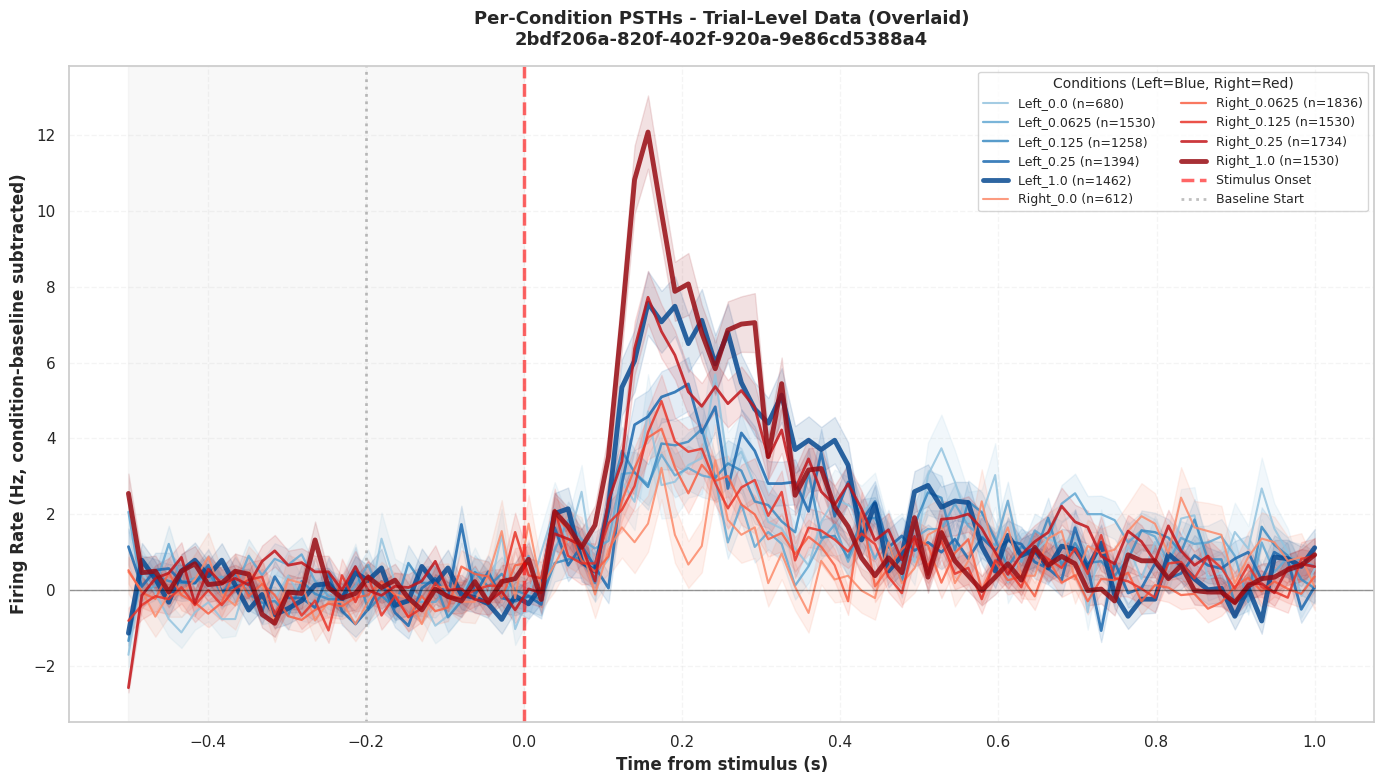


✓ Per-condition PSTHs plotted from trial-level data
  Each colored line represents a different condition
  Different traces show condition-specific effects


In [32]:
# =====================================================================
# EXAMPLE: Per-condition PSTH from TRIAL-LEVEL data
# =====================================================================
# Load raw trial-level firing rates directly from files
# (The raw files contain trial_id and condition columns)

print("Loading trial-level firing rates for example session...\n")

pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])

# Search for a file with neurons in target regions AND conditions
raw_data = None
good_session = None

for pkl_file in pkl_files:
    filepath = os.path.join(firing_rates_dir, pkl_file)
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    # Filter to target regions
    filtered = data[data['area'].isin(BRAIN_REGIONS)]
    
    if len(filtered) > 0 and 'condition' in filtered.columns:
        conditions = filtered['condition'].dropna().nunique()
        if conditions > 0:
            raw_data = data
            good_session = filtered['session'].iloc[0]
            print(f"✓ Found suitable session in: {pkl_file}")
            break

if raw_data is None:
    print("✗ Could not find session with neurons in target regions")
else:
    example_session = good_session
    
    # Filter to example session and target brain regions
    session_data = raw_data[raw_data['session'] == example_session].copy()
    session_data = session_data[session_data['area'].isin(BRAIN_REGIONS)]
    
    print(f"  Session: {example_session}")
    print(f"  Neurons: {session_data['neuron_id'].nunique()}")
    print(f"  Total trials: {len(session_data)}")
    
    # Get conditions
    conditions_example = sorted(session_data['condition'].dropna().unique())
    print(f"  Conditions: {len(conditions_example)}")
    print(f"  {conditions_example}\n")
    
    # Extract time columns and identify baseline
    time_cols = [col for col in session_data.columns if col.startswith('t_')]
    time_values = np.array([float(col.split('_')[1]) for col in time_cols])
    baseline_mask = (time_values >= -0.2) & (time_values <= 0)
    baseline_cols = [col for col, mask in zip(time_cols, baseline_mask) if mask]
    
    # =====================================================================
    # Calculate per-condition PSTH
    # =====================================================================
    condition_psts = {}
    
    for condition in conditions_example:
        if pd.isna(condition):
            continue
            
        condition_data = session_data[session_data['condition'] == condition]
        
        # Calculate baseline for this condition
        baseline_vals = condition_data[baseline_cols].values
        condition_baseline = np.nanmean(baseline_vals)
        
        # Get firing rates for this condition and subtract baseline
        firing_rates = condition_data[time_cols].values.astype(float)
        firing_rates_normalized = firing_rates - condition_baseline
        
        # Calculate mean and SEM across trials
        mean_psth = np.nanmean(firing_rates_normalized, axis=0)
        std_psth = np.nanstd(firing_rates_normalized, axis=0)
        sem_psth = std_psth / np.sqrt(firing_rates_normalized.shape[0])
        
        n_trials = len(condition_data)
        
        condition_psts[condition] = {
            'mean': mean_psth,
            'sem': sem_psth,
            'n_trials': n_trials
        }
        print(f"  {condition}: {n_trials} trials")
    
    # =====================================================================
    # Plot per-condition PSTHs overlaid
    # =====================================================================
    # Color palette
    colors_by_condition = {}
    left_conditions = [c for c in conditions_example if 'Left' in c and not pd.isna(c)]
    right_conditions = [c for c in conditions_example if 'Right' in c and not pd.isna(c)]
    
    cool_cmap = cm.Blues(np.linspace(0.4, 0.9, max(1, len(left_conditions))))
    warm_cmap = cm.Reds(np.linspace(0.4, 0.9, max(1, len(right_conditions))))
    
    for i, cond in enumerate(left_conditions):
        colors_by_condition[cond] = cool_cmap[i]
    for i, cond in enumerate(right_conditions):
        colors_by_condition[cond] = warm_cmap[i]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot each condition
    for condition in conditions_example:
        if condition not in condition_psts:
            continue
            
        mean_psth = condition_psts[condition]['mean']
        sem_psth = condition_psts[condition]['sem']
        n_trials = condition_psts[condition]['n_trials']
        
        stim_side, contrast_val = condition.split('_')
        contrast_float = float(contrast_val)
        
        # Line thickness by contrast
        linewidth = 1.5 + (contrast_float * 2)
        
        # Plot
        ax.plot(time_values, mean_psth,
                label=f'{condition} (n={n_trials})',
                linewidth=linewidth,
                color=colors_by_condition[condition],
                alpha=0.85)
        
        # Error band
        ax.fill_between(time_values,
                        mean_psth - sem_psth,
                        mean_psth + sem_psth,
                        alpha=0.12,
                        color=colors_by_condition[condition])
    
    # Reference lines
    ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=2.5, label='Stimulus Onset')
    ax.axvline(-0.2, color='grey', linestyle=':', alpha=0.5, linewidth=2, label='Baseline Start')
    ax.axhline(0, color='black', linestyle='-', alpha=0.4, linewidth=1)
    
    # Labels and styling
    ax.set_xlabel('Time from stimulus (s)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Firing Rate (Hz, condition-baseline subtracted)', fontsize=12, fontweight='bold')
    ax.set_title(f'Per-Condition PSTHs - Trial-Level Data (Overlaid)\n{example_session}', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=9, loc='best', frameon=True, ncol=2,
              title='Conditions (Left=Blue, Right=Red)', title_fontsize=10)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.axvspan(-0.5, 0, alpha=0.05, color='grey')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Per-condition PSTHs plotted from trial-level data")
    print(f"  Each colored line represents a different condition")
    print(f"  Different traces show condition-specific effects")


FINAL AGGREGATION: Condition-averaged firing rates by LDA bins

Averaging strategy:
1. Each condition (stim_side + contrast) gets baseline-subtracted per session
2. All conditions averaged together within each session
3. Sessions grouped by LDA_1 behavioral alignment
4. Result: Aggregate stimulus response across all conditions



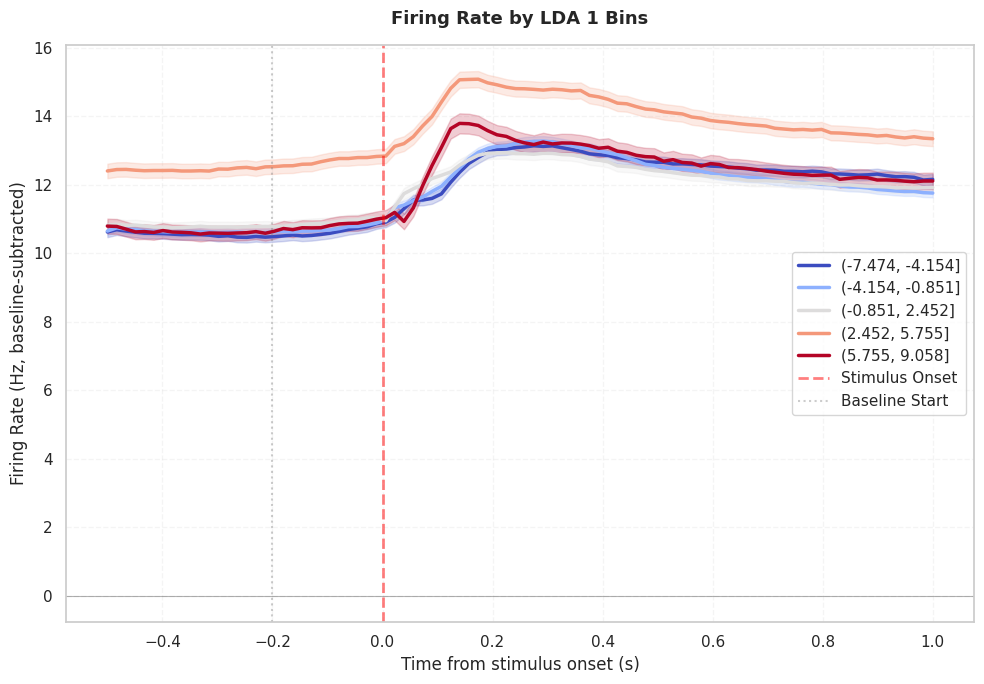


✓ Aggregated PSTH plotted across 5 LDA bins
  Baseline period (-0.2 to 0s) normalized to zero
  Post-stimulus range shows condition-averaged neural response


In [35]:
# =====================================================================
# FINAL PLOT: Aggregated PSTH by LDA bins
# =====================================================================
# This plot shows firing rates averaged within conditions, then across LDA bins
# Processing steps:
# 1. Subtract condition-specific baseline for each session
# 2. Average neurons across all conditions for each session
# 3. Group sessions by LDA_1 bins and average

print("\n" + "=" * 80)
print("FINAL AGGREGATION: Condition-averaged firing rates by LDA bins")
print("=" * 80)
print("""
Averaging strategy:
1. Each condition (stim_side + contrast) gets baseline-subtracted per session
2. All conditions averaged together within each session
3. Sessions grouped by LDA_1 behavioral alignment
4. Result: Aggregate stimulus response across all conditions
""")

# Sort bins and create color palette
sorted_bins = sorted(averaged_by_bin.index.tolist())
colors = cm.coolwarm(np.linspace(0, 1, len(sorted_bins)))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each bin's PSTH
for i, bin_label in enumerate(sorted_bins):
    mean_values = averaged_by_bin.loc[bin_label].values
    error_values = stderr_by_bin.loc[bin_label].values
    
    # Plot the main line
    ax.plot(time_values, mean_values,
            label=bin_label,
            linewidth=2.5,
            color=colors[i])
    
    # Add error bands (mean ± standard error)
    ax.fill_between(time_values,
                    mean_values - error_values,
                    mean_values + error_values,
                    alpha=0.2,
                    color=colors[i])

# Add vertical lines for important timepoints
ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Stimulus Onset')
ax.axvline(-0.2, color='grey', linestyle=':', alpha=0.4, linewidth=1.5, label='Baseline Start')
ax.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)  # Baseline reference line

# Labels and styling
ax.set_xlabel('Time from stimulus onset (s)', fontsize=12)
ax.set_ylabel('Firing Rate (Hz, baseline-subtracted)', fontsize=12)
ax.set_title('Firing Rate by LDA 1 Bins', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', frameon=True)
ax.grid(True, alpha=0.2, linestyle='--')
# plt.ylim([10, 16])
plt.tight_layout()
plt.show()

print(f"\n✓ Aggregated PSTH plotted across {len(sorted_bins)} LDA bins")
print(f"  Baseline period (-0.2 to 0s) normalized to zero")
print(f"  Post-stimulus range shows condition-averaged neural response")